<a href="https://colab.research.google.com/github/Venky404/Google-Colab-Assignment/blob/main/Assignment26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import required libraries

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



Q1. Create Synthetic Dataset

In [2]:
# Generate synthetic dataset
X, y = make_blobs(
    n_samples=500,
    centers=4,
    cluster_std=0.70,
    random_state=42
)

# Convert into DataFrame
df = pd.DataFrame(X, columns=["Feature1", "Feature2"])

# Display first 10 rows
print("First 10 Rows:")
print(df.head(10))

# Display shape
print("\nDataset Shape:", df.shape)

First 10 Rows:
   Feature1  Feature2
0 -8.033836  6.831299
1 -8.767448 -6.918116
2  6.172741  1.407361
3 -2.783673  7.989826
4 -6.038777 -7.165762
5 -6.298392 -7.479368
6 -7.046269  7.256281
7 -6.690307 -6.915276
8  3.892545  1.873504
9 -7.317000 -6.861846

Dataset Shape: (500, 2)


Q2. Apply Standard Scaling

In [3]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

# Display first 5 rows
print("\nFirst 5 Rows of Scaled Data:")
print(pd.DataFrame(X_scaled, columns=["Feature1", "Feature2"]).head())


First 5 Rows of Scaled Data:
   Feature1  Feature2
0 -0.888474  0.629907
1 -1.028908 -1.562875
2  1.831069 -0.235113
3  0.116557  0.814671
4 -0.506563 -1.602370


Q3. Apply K-Means Clustering

In [4]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to DataFrame
df["Cluster"] = clusters

# Display updated DataFrame
print("\nUpdated DataFrame:")
print(df.head(10))


Updated DataFrame:
   Feature1  Feature2  Cluster
0 -8.033836  6.831299        1
1 -8.767448 -6.918116        2
2  6.172741  1.407361        0
3 -2.783673  7.989826        1
4 -6.038777 -7.165762        2
5 -6.298392 -7.479368        2
6 -7.046269  7.256281        1
7 -6.690307 -6.915276        2
8  3.892545  1.873504        0
9 -7.317000 -6.861846        2


 Q4. Visualizing Clusters

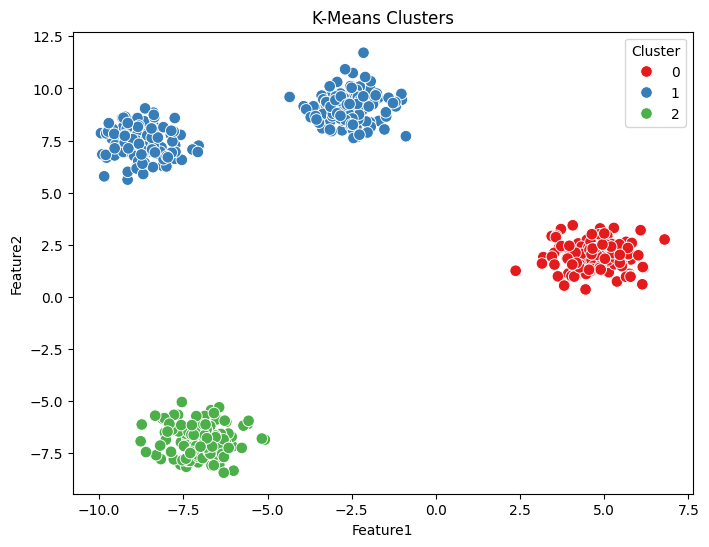

In [5]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Feature1",
    y="Feature2",
    hue="Cluster",
    palette="Set1",
    s=70
)

plt.title("K-Means Clusters")
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.legend(title="Cluster")
plt.show()

Q5. Elbow Method

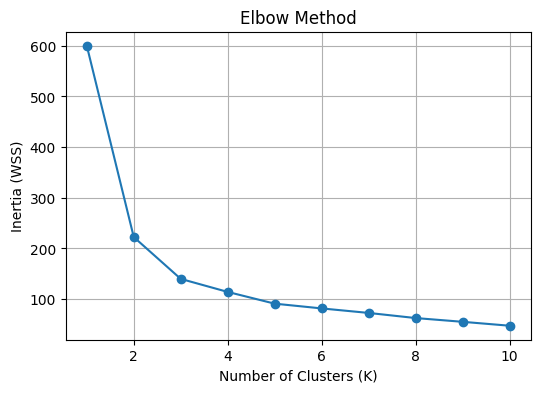

Observation:
The optimal K is usually where the graph forms an 'elbow'.
For this dataset, it is expected to be around K = 4.


In [13]:
inertia = []

for k in range(1, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (WSS)")
plt.grid(True)
plt.show()

print("Observation:")
print("The optimal K is usually where the graph forms an 'elbow'.")
print("For this dataset, it is expected to be around K = 4.")



Q6. Final K-Means Model

In [7]:
optimal_k = 4

final_model = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

final_clusters = final_model.fit_predict(X_scaled)

df["Final_Cluster"] = final_clusters

print("\nNumber of Data Points in Each Cluster:")
print(df["Final_Cluster"].value_counts())


Number of Data Points in Each Cluster:
Final_Cluster
1    125
2    125
0    125
3    125
Name: count, dtype: int64


Q7. Visualizing Final Clusters

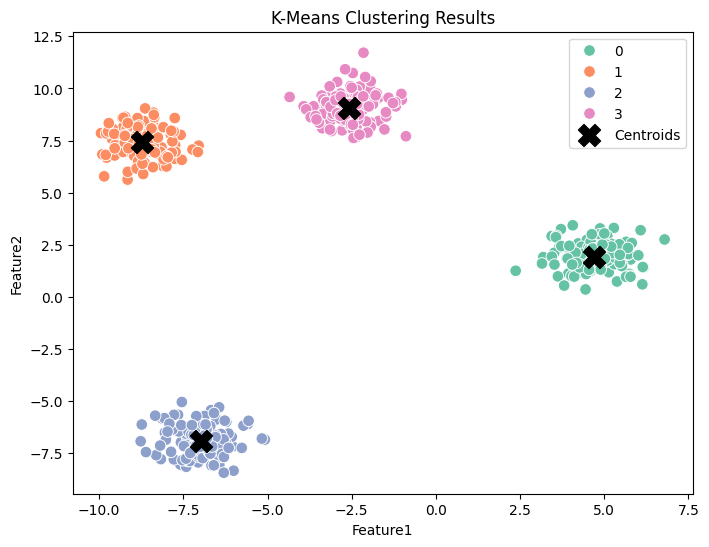

In [8]:

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["Feature1"],
    y=df["Feature2"],
    hue=df["Final_Cluster"],
    palette="Set2",
    s=70
)

# Plot Centroids
centroids = scaler.inverse_transform(final_model.cluster_centers_)

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    c="black",
    marker="X",
    s=250,
    label="Centroids"
)

plt.title("K-Means Clustering Results")
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.legend()
plt.show()

Q8. Real Dataset Application

In [10]:
# Load Iris dataset
iris = load_iris()

# Create DataFrame
iris_df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Display first 5 rows
print("First 5 Rows:")
print(iris_df.head())

# Select numerical features
X = iris_df

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply KMeans
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

iris_df["Cluster"] = kmeans.fit_predict(X_scaled)

# Display cluster counts
print("\nCluster Counts:")
print(iris_df["Cluster"].value_counts())



First 5 Rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Cluster Counts:
Cluster
0    53
1    50
2    47
Name: count, dtype: int64


 Q9. Elbow Method on Iris Dataset

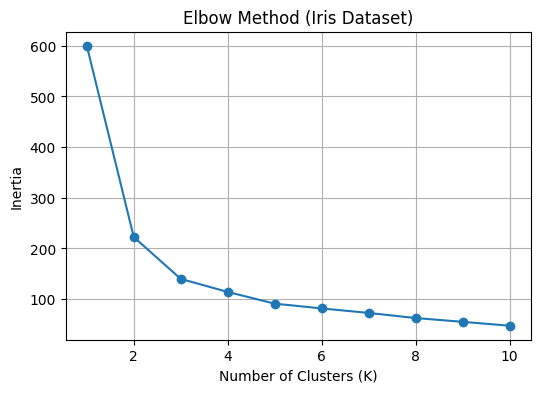

Observation:
The elbow is generally observed around K = 3.


In [14]:
inertia = []

for k in range(1, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,11), inertia, marker='o')
plt.title("Elbow Method (Iris Dataset)")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

print("Observation:")
print("The elbow is generally observed around K = 3.")


# Train Final Model
final_model = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

iris_df["Final_Cluster"] = final_model.fit_predict(X_scaled)

Q10. Mini Project – Complete Clustering Pipeline


===== MINI PROJECT =====

Dataset Shape: (150, 7)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Cluster            150 non-null    int32  
 5   Final_Cluster      150 non-null    int32  
 6   Project_Cluster    150 non-null    int32  
dtypes: float64(4), int32(3)
memory usage: 6.6 KB
None

Statistical Summary:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1

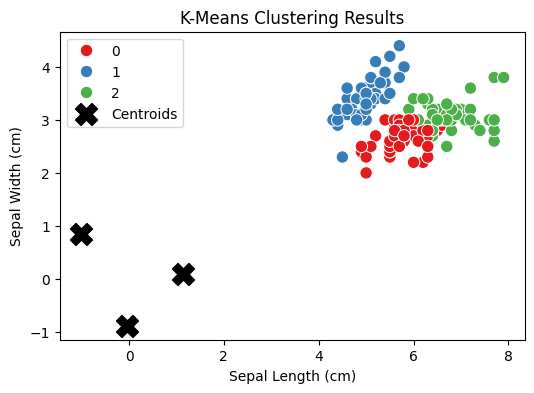

In [15]:
print("\n===== MINI PROJECT =====")

# Step 1 : Load & Explore
print("\nDataset Shape:", iris_df.shape)

print("\nDataset Information:")
print(iris_df.info())

print("\nStatistical Summary:")
print(iris_df.describe())

# Step 2 : Numerical Features
X = iris_df.iloc[:, :4]

# Step 3 : Scale Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 4 : Train Final Model
final_model = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = final_model.fit_predict(X_scaled)

iris_df["Project_Cluster"] = clusters

print("\nProject Cluster Counts:")
print(iris_df["Project_Cluster"].value_counts())

# Step 5 : Visualize Clusters
plt.figure(figsize=(6,4))

sns.scatterplot(
    data=iris_df,
    x="sepal length (cm)",
    y="sepal width (cm)",
    hue="Project_Cluster",
    palette="Set1",
    s=80
)

plt.scatter(
    final_model.cluster_centers_[:,0],
    final_model.cluster_centers_[:,1],
    c="black",
    marker="X",
    s=250,
    label="Centroids"
)

plt.title("K-Means Clustering Results")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.legend()
plt.show()